In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ta.trend import SMAIndicator, EMAIndicator, MACD
from ta.momentum import RSIIndicator

plt.style.use("ggplot")

In [3]:
import pandas as pd

aapl = pd.read_csv("../data/raw/AAPL.csv")

aapl.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [4]:
aapl.info()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   str    
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 213.9 KB


In [5]:
aapl["Date"] = pd.to_datetime(aapl["Date"])

aapl = aapl.sort_values("Date")

aapl.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [6]:
# Simple Moving Average
aapl["SMA_20"] = SMAIndicator(close=aapl["Close"], window=20).sma_indicator()

# Exponential Moving Average
aapl["EMA_20"] = EMAIndicator(close=aapl["Close"], window=20).ema_indicator()

# RSI
aapl["RSI"] = RSIIndicator(close=aapl["Close"], window=14).rsi()

# MACD
macd = MACD(close=aapl["Close"])

aapl["MACD"] = macd.macd()
aapl["MACD_SIGNAL"] = macd.macd_signal()

aapl.head()

,Date,Close,High,Low,Open,Volume,SMA_20,EMA_20,RSI,MACD,MACD_SIGNAL
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,NaN,NaN,NaN,NaN,NaN
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,NaN,NaN,NaN,NaN,NaN
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,NaN,NaN,NaN,NaN,NaN
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,NaN,NaN,NaN,NaN,NaN
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,NaN,NaN,NaN,NaN,NaN


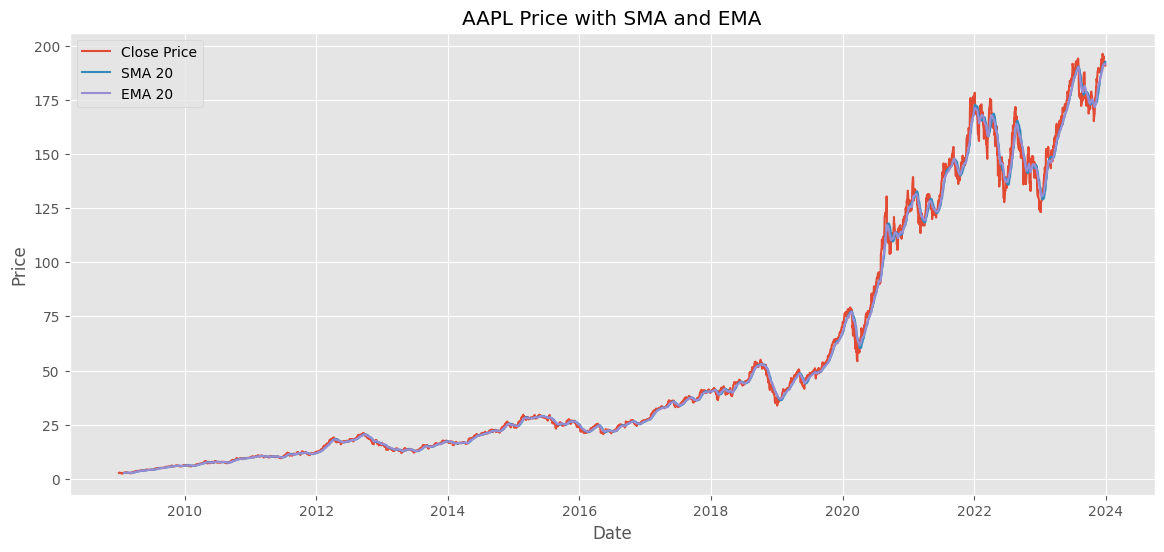

In [7]:
plt.figure(figsize=(14,6))

plt.plot(aapl["Date"], aapl["Close"], label="Close Price")
plt.plot(aapl["Date"], aapl["SMA_20"], label="SMA 20")
plt.plot(aapl["Date"], aapl["EMA_20"], label="EMA 20")

plt.title("AAPL Price with SMA and EMA")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()

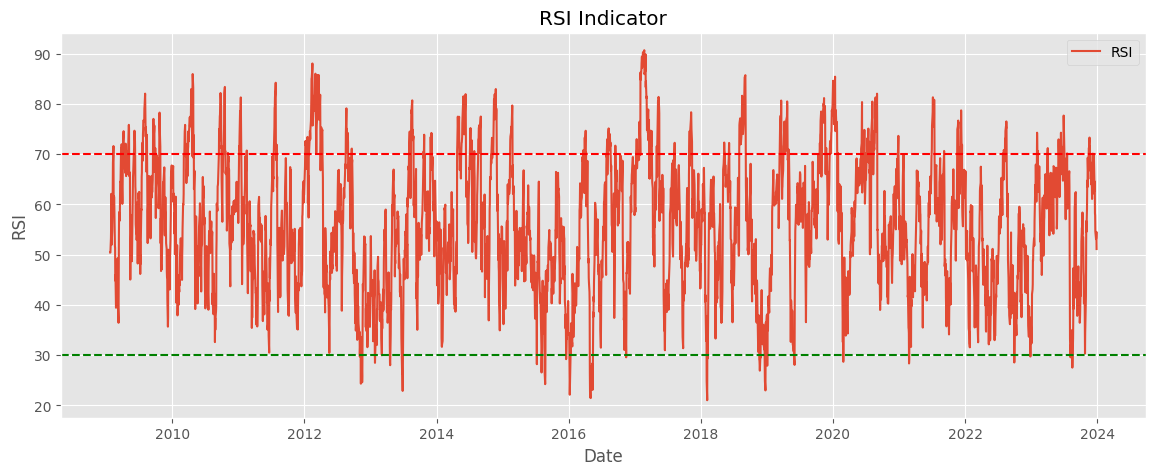

In [8]:
plt.figure(figsize=(14,5))

plt.plot(aapl["Date"], aapl["RSI"], label="RSI")

plt.axhline(70, color="red", linestyle="--")
plt.axhline(30, color="green", linestyle="--")

plt.title("RSI Indicator")
plt.xlabel("Date")
plt.ylabel("RSI")

plt.legend()

plt.show()

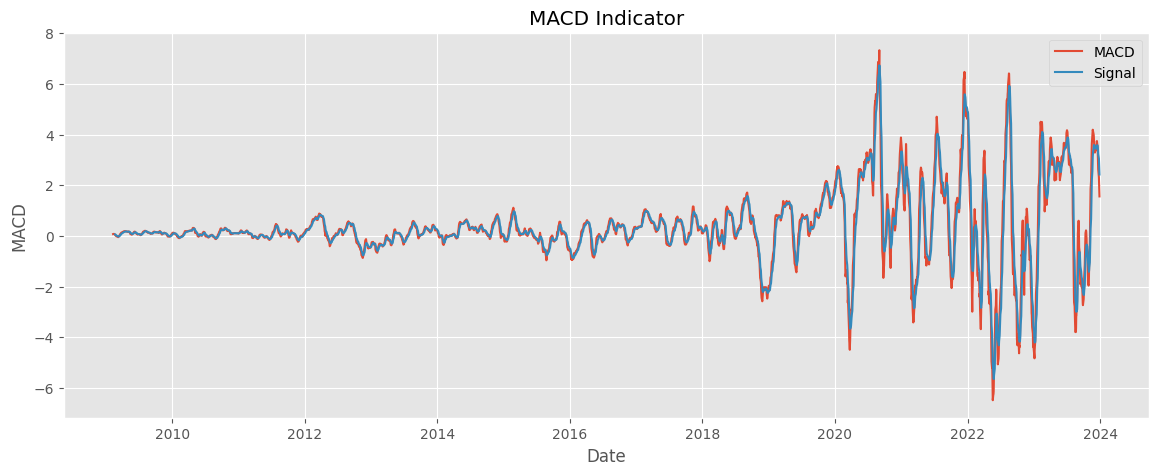

In [9]:
plt.figure(figsize=(14,5))

plt.plot(aapl["Date"], aapl["MACD"], label="MACD")
plt.plot(aapl["Date"], aapl["MACD_SIGNAL"], label="Signal")

plt.title("MACD Indicator")
plt.xlabel("Date")
plt.ylabel("MACD")

plt.legend()

plt.show()

# Key Insights

- The SMA and EMA indicators show the general trend direction of AAPL stock.
- RSI values above 70 suggest overbought conditions, while values below 30 suggest oversold conditions.
- MACD crossovers indicate potential bullish or bearish momentum shifts.
- The stock demonstrates periods of strong momentum and trend reversals.
- Technical indicators provide insights into possible investment decisions.

In [10]:
import pandas as pd

aapl = pd.read_csv("../data/raw/AAPL.csv")
amzn = pd.read_csv("../data/raw/AMZN.csv")
goog = pd.read_csv("../data/raw/GOOG.csv")
meta = pd.read_csv("../data/raw/META.csv")
nvda = pd.read_csv("../data/raw/NVDA.csv")

In [11]:
print(aapl.head())
print(amzn.head())
print(goog.head())
print(meta.head())
print(nvda.head())


         Date     Close      High       Low      Open      Volume
0  2009-01-02  2.721686  2.730385  2.554037  2.575630   746015200
1  2009-01-05  2.836553  2.884539  2.780469  2.794266  1181608400
2  2009-01-06  2.789767  2.914229  2.770872  2.877641  1289310400
3  2009-01-07  2.729484  2.774170  2.706990  2.753477   753048800
4  2009-01-08  2.780169  2.793666  2.700393  2.712090   673500800
         Date  Close    High     Low    Open     Volume
0  2009-01-02  2.718  2.7265  2.5535  2.5675  145928000
1  2009-01-05  2.703  2.7870  2.6515  2.7865  190196000
2  2009-01-06  2.868  2.9110  2.6875  2.7275  221602000
3  2009-01-07  2.810  2.8475  2.7675  2.8145  158854000
4  2009-01-08  2.858  2.8660  2.7290  2.7495  131558000
         Date     Close      High       Low      Open     Volume
0  2009-01-02  7.948608  7.960977  7.557264  7.633949  144961322
1  2009-01-05  8.115089  8.194003  7.792268  7.940692  196293007
2  2009-01-06  8.263762  8.430492  8.074027  8.237046  257971329
3  2009-

In [12]:
stocks = ["AAPL", "AMZN", "GOOG", "META", "NVDA"]

data = {}

for stock in stocks:
    df = pd.read_csv(f"../data/raw/{stock}.csv")
    data[stock] = df
    print(f"{stock} loaded successfully")

AAPL loaded successfully
AMZN loaded successfully
GOOG loaded successfully
META loaded successfully
NVDA loaded successfully


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ta.trend import SMAIndicator, EMAIndicator, MACD
from ta.momentum import RSIIndicator